In [10]:
from dataset.dataset import FSARMultisportsDatasetTrain
import torch 
import pickle


data_root = "multisports_data/data/trainval"
ground_truth_path="multisports_fewshot_GT.pkl"

with open(ground_truth_path, "rb") as file:
    data = pickle.load(file)

print(data.keys())

dict_keys(['train_labels', 'validation_labels', 'test_labels', 'train_videos', 'test_videos', 'validation_videos', 'nframes', 'resolution', 'gttubes'])


Building DataLoader...
Success! DataLoader has 543 total batches.

Fetching the first batch...
--- Batch 0 ---
Tubelets shape: torch.Size([16, 3, 16, 224, 224])
Labels shape:   torch.Size([16])

Tubelets dtype: torch.float32
Labels dtype:   torch.int64

aerobic split jump
Tubelets Min value: -2.1179
Tubelets Max value: 2.6400

Spawning visualization window... (Close the window to end the test)


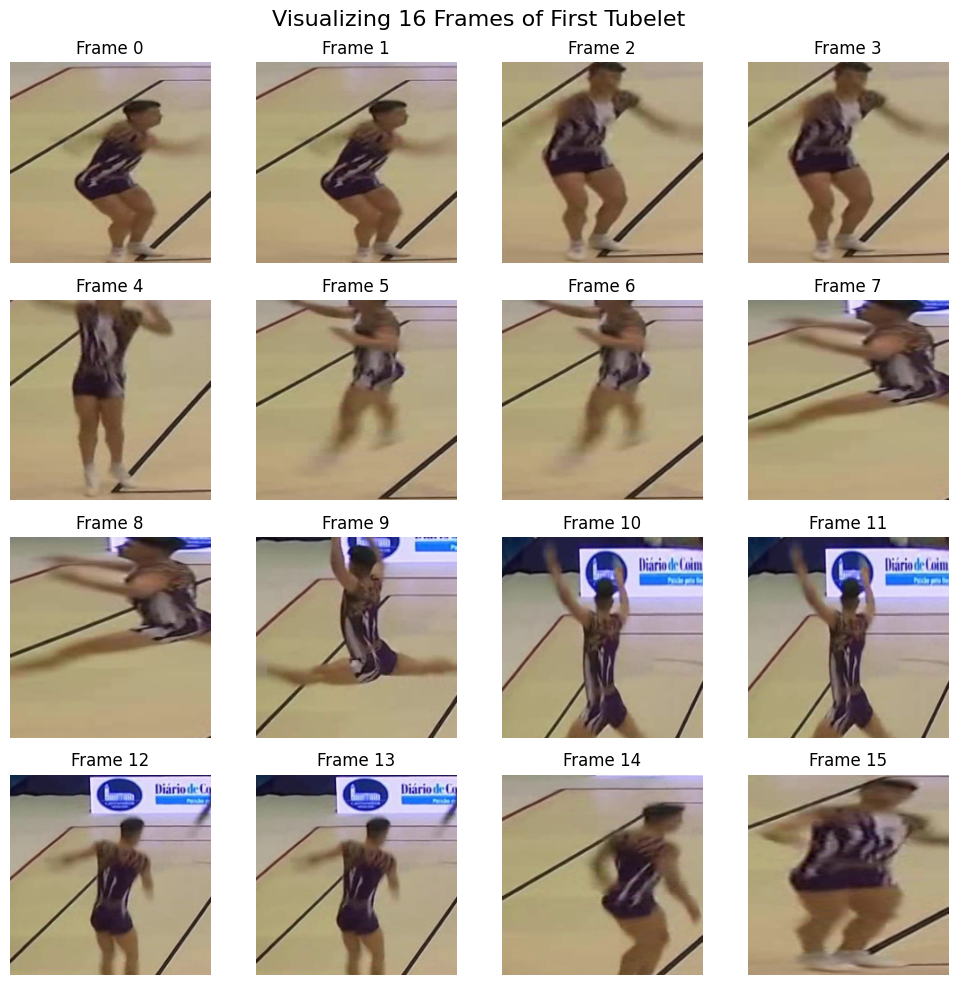


Test Complete!


In [17]:
import torch
import matplotlib.pyplot as plt # <-- 1. Add matplotlib
import numpy as np
from dataset.dataloader import build_train_dataloader 
from config import Config

def visualize_tubelet(tubelet_tensor):
    """
    Takes a single tubelet tensor, denormalizes it, and plots a 4x4 grid.
    Handles both [C, T, H, W] and [T, C, H, W] formats.
    """
    # Move to CPU just in case
    tubelet_tensor = tubelet_tensor.cpu()
    
    # Check if tensor is [C, T, H, W] (due to your permute(1,0,2,3) in dataset)
    # If so, swap it to [T, C, H, W] so we can iterate over frames
    if tubelet_tensor.shape[0] == 3:
        tubelet_tensor = tubelet_tensor.permute(1, 0, 2, 3)
        
    # --- Denormalize ---
    # DINOv2 ImageNet stats
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    
    # Reverse the normalization: Image = (Normalized_Image * std) + mean
    tubelet_tensor = tubelet_tensor * std + mean
    
    # Clamp to [0, 1] to fix any tiny floating point rounding errors
    tubelet_tensor = torch.clamp(tubelet_tensor, 0, 1)
    
    # --- Plotting ---
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle("Visualizing 16 Frames of First Tubelet", fontsize=16)
    
    for i, ax in enumerate(axes.flatten()):
        if i < tubelet_tensor.shape[0]:
            # Convert from [C, H, W] to [H, W, C] for Matplotlib
            img = tubelet_tensor[i].permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.set_title(f"Frame {i}")
        ax.axis("off") # Hide axes for cleaner look
        
    plt.tight_layout()
    plt.show()

# 3. Protect the execution loop for Windows multiprocessing
if __name__ == '__main__':
    
    cfg = Config()
    print("Building DataLoader...")
    
    # Instantiate the dataloader
    dataloader = build_train_dataloader(cfg)
    print(f"Success! DataLoader has {len(dataloader)} total batches.\n")
    
    # 4. Iterate through the dataloader
    print("Fetching the first batch...")
    for batch_idx, (tubelets, labels) in enumerate(dataloader):
        
        print(f"--- Batch {batch_idx} ---")
        
        print(f"Tubelets shape: {tubelets.shape}") 
        print(f"Labels shape:   {labels.shape}\n")
        
        print(f"Tubelets dtype: {tubelets.dtype}")
        print(f"Labels dtype:   {labels.dtype}\n")
        print(dataloader.dataset.label_dict[labels[0]])
        
        print(f"Tubelets Min value: {tubelets.min().item():.4f}")
        print(f"Tubelets Max value: {tubelets.max().item():.4f}")
        
        # --- Add visualization here! ---
        print("\nSpawning visualization window... (Close the window to end the test)")
        # Grab the very first tubelet in the batch: tubelets[0]
        visualize_tubelet(tubelets[0])
        
        # We only need one batch to verify it works, so break the loop early
        break
    
    print("\nTest Complete!")